# Movie Recommendation System - EDA and Modeling

This notebook demonstrates the Exploratory Data Analysis (EDA) and the process of building a Hybrid Movie Recommendation System using the MovieLens dataset.

## 1. Load the Data
Initially, we import libraries and load our datasets (`movies`, `ratings`, and `tags`).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Adjust the path depending on where you run this notebook
movies = pd.read_csv('../data/ml-latest-small/movies.csv')
ratings = pd.read_csv('../data/ml-latest-small/ratings.csv')

print("Movies dataset shape:", movies.shape)
print("Ratings dataset shape:", ratings.shape)
display(movies.head())
display(ratings.head())

Movies dataset shape: (9742, 3)
Ratings dataset shape: (100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 2. Exploratory Data Analysis (EDA)
Let's check for missing values and plot rating distributions.

Missing values in Movies:
 movieId    0
title      0
genres     0
dtype: int64

Missing values in Ratings:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_22492\1225498129.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='viridis')


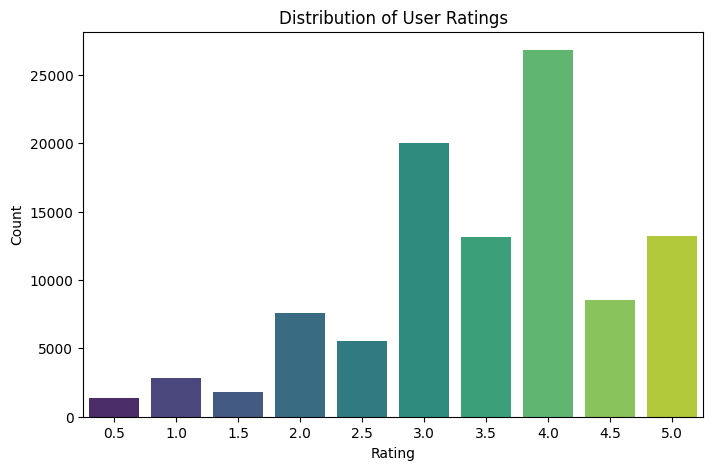

In [3]:
# Check missing values
print("Missing values in Movies:\n", movies.isnull().sum())
print("\nMissing values in Ratings:\n", ratings.isnull().sum())

# Distribution of Ratings
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title('Distribution of User Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

Let's analyze popular genres.

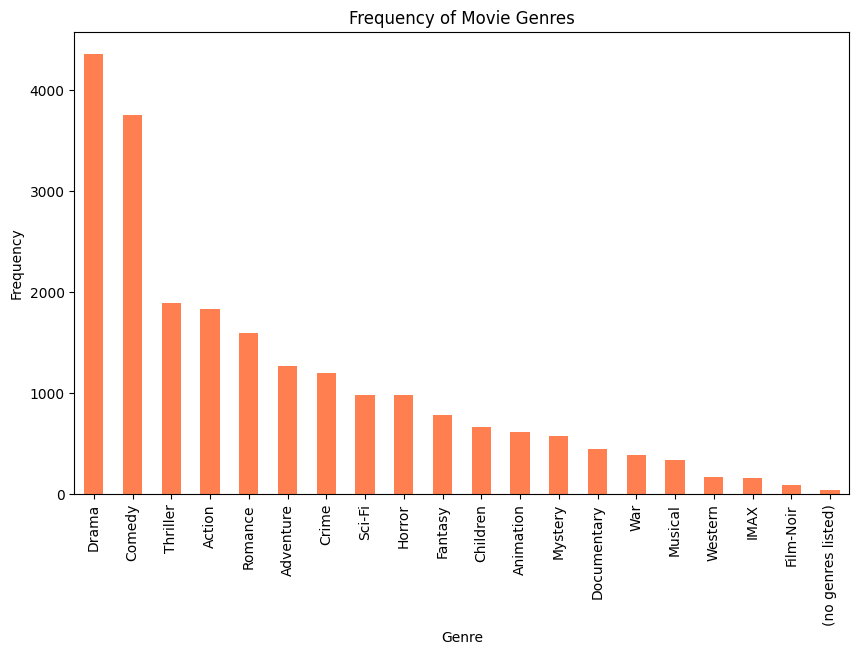

In [4]:
# Splitting genres and counting frequencies
all_genres = [genre for genres in movies['genres'].str.split('|') for genre in genres]
genres_series = pd.Series(all_genres)

plt.figure(figsize=(10, 6))
genres_series.value_counts().plot(kind='bar', color='coral')
plt.title('Frequency of Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Frequency')
plt.show()

## 3. Collaborative Filtering with Matrix Factorization (TruncatedSVD)
We will use the `scikit-learn` library to train a Singular Value Decomposition (SVD) model on the User-Item rating matrix.

In [5]:
from sklearn.decomposition import TruncatedSVD

# Create User-Item Matrix
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)

svd = TruncatedSVD(n_components=20, random_state=42)
latent_matrix = svd.fit_transform(user_item_matrix)
predicted_ratings = np.dot(latent_matrix, svd.components_)

actual = user_item_matrix.values
mask = actual > 0
mse = np.mean((actual[mask] - predicted_ratings[mask]) ** 2)
rmse = np.sqrt(mse)
print(f"Collaborative Filtering RMSE: {rmse:.4f}")

Collaborative Filtering RMSE: 2.3626


## 4. Content-Based Filtering using TF-IDF
We will convert the genres into text vectors and measure Cosine Similarity between movies.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

movies['genres_cleaned'] = movies['genres'].str.replace('|', ' ')
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres_cleaned'])

cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
print("Cosine Similarity Matrix Shape:", cosine_sim.shape)

TF-IDF Matrix Shape: (9742, 23)
Cosine Similarity Matrix Shape: (9742, 9742)


## 5. Summary
We have explored the dataset, analyzed its properties, computed the CF (SVD model), and extracted textual features for CB. These models are combined in the Hybrid Recommender System, which assigns a recommendation by using CF estimated ratings on movies retrieved via Content-Based similarity.